In [1]:
%matplotlib qt
import mne
import pickle
import numpy as np
import os.path as op
import matplotlib.pyplot as plt

In [2]:
def save_bipolar_connections(cnx, fname_bipolar_connections='fname.pickle'):
    with open(fname_bipolar_connections, 'wb') as f:
        pickle.dump(cnx, f, pickle.HIGHEST_PROTOCOL)
    return None

def load_bipolar_connections(fname_bipolar_connections):
    with open(fname_bipolar_connections, 'rb') as f:
        return pickle.load(f)

In [6]:
# Read preprocessed EEG data
data_path = op.expanduser('~/data/wash-u/preprocessed/')
fname_raw = '7005_4_rest1_ec_eeg.fif'
fpath_raw = op.join(data_path, fname_raw)
raw = mne.io.read_raw_fif(fpath_raw)
raw.crop(tmin=157, tmax=217) # pseudo-resting data interval
raw.load_data()

Opening raw data file /Users/chholakp2/data/wash-u/preprocessed/7005_4_rest1_ec_eeg.fif...
Isotrak not found
    Range : 0 ... 155879 =      0.000 ...   311.758 secs
Ready.
Reading 0 ... 30000  =      0.000 ...    60.000 secs...


<Raw | 7005_4_rest1_ec_eeg.fif, 34 x 30001 (60.0 s), ~7.8 MB, data loaded>

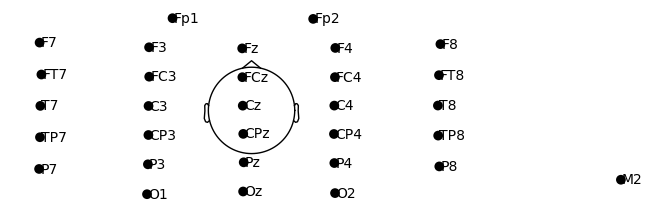

In [4]:
raw.plot_sensors(show_names=True)

For Bipolar Connection scheme, see Fig. 4 in [Book]-Electroencephalography-Louis&Frey.pdf

In [ ]:
bipolar_cnx = {
    1: ('Fp1', 'F7'),
    2: ('F7', 'FT7'),
    3: ('FT7', 'T7'),
    4: ('T7', 'TP7'),
    5: ('TP7', 'P7'),
    6: ('P7', 'O1'),
    7: ('Fp1', 'F3'),
    8: ('F3', 'FC3'),
    9: ('FC3', 'C3'),
    10: ('C3', 'CP3'),
    11: ('CP3', 'P3'),
    12: ('P3', 'O1'),
    13: ('Fz', '05'),
    14: ('FCz', '09'),
    15: ('Cz', '19'),
    16: ('CPz', '27'),
    17: ('Pz', 'Oz'),
    18: ('45', '54'),
    19: ('54', '57'),
    20: ('05', '10'),
    21: ('10', '28'),
    22: ('28', '38'),
    23: ('38', '46'),
    24: ('46', '54'),
    25: ('01', '11'),
    26: ('11', '20'),
    27: ('20', '29'),
    28: ('29', '39'),
    29: ('39', '47'),
    30: ('47', '57'),
    31: ('03', '07'),
    32: ('07', '16'),
    33: ('16', '23'),
    34: ('23', '24'),
    35: ('24', '35'),
    36: ('35', '43'),
    37: ('43', '52'),
    38: ('52', '56'),
    39: ('56', '59'),
    40: ('23', '34'),
    41: ('34', '42'),
    42: ('42', '52'),
    43: ('03', '06'),
    44: ('06', '15'),
    45: ('15', '22'),
    46: ('22', '33'),
    47: ('33', '51'),
    48: ('51', '55'),
    49: ('55', '59'),
    50: ('06', '14'),
    51: ('14', '32'),
    52: ('32', '41'),
    53: ('41', '50'),
    54: ('50', '55'),
    55: ('03', '13'),
    56: ('13', '21'),
    57: ('21', '31'),
    58: ('31', '40'),
    59: ('40', '49'),
    60: ('49', '59'),
    61: ('02', '12'),
    62: ('12', '30'),
    63: ('30', '48'),
    64: ('48', '58'),
    65: ('58', '60'),
}

In [ ]:
save_bipolar_connections(bipolar_cnx)

In [ ]:
bipolar_cnx_loaded = load_bipolar_connections('bipolar_connections.pickle')

In [ ]:
anode = []; cathode = []
for a, c in bipolar_cnx_loaded.values():
    anode.append(a); cathode.append(c)

In [7]:
raw_bip_ref = mne.set_bipolar_reference(raw, anode=['Fp1'], cathode=['F7'])

EEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=30001
    Range : 78500 ... 108500 =    157.000 ...   217.000 secs
Ready.
Added the following bipolar channels:
Fp1-F7


Using matplotlib as 2D backend.


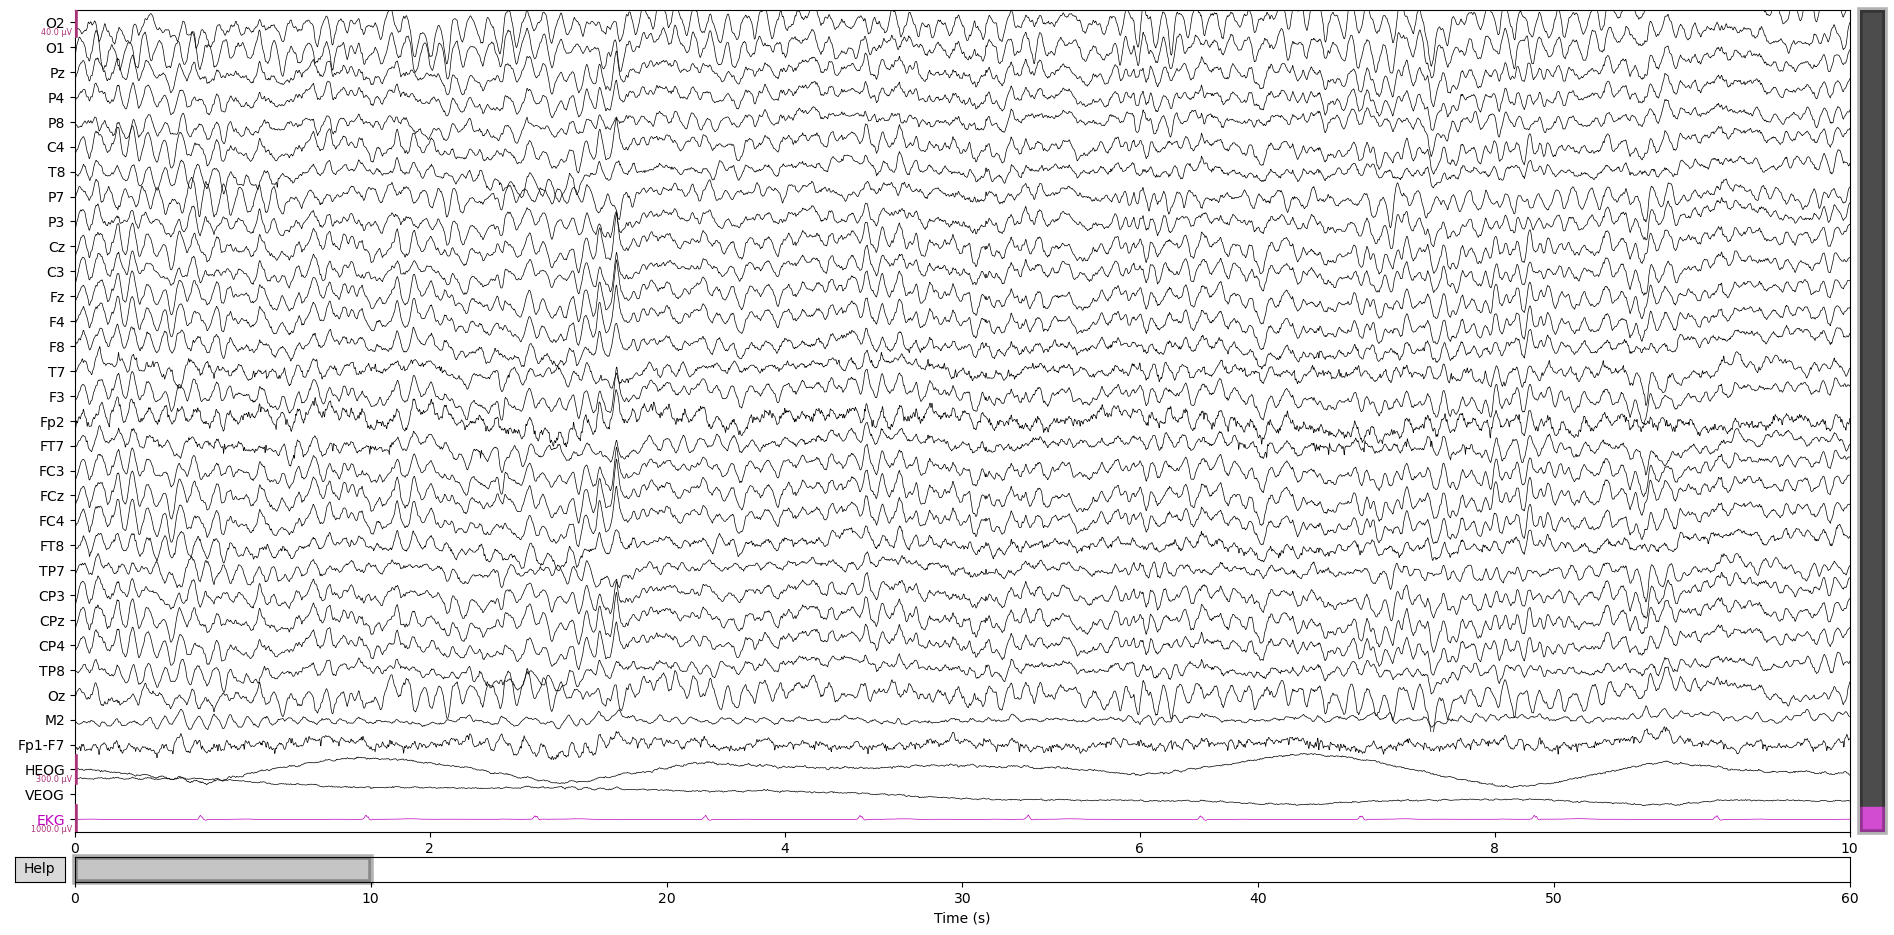

Channels marked as bad:
none


In [8]:
raw_bip_ref.plot(n_channels=len(raw_bip_ref.ch_names))